# D02 – Feature-Engineered Dataset(s)
## The "Value-for-Money" Transfer Scout
*Group 7: Megann Kouandjeu, Salma Kamoun, Axel Chartier*

---

### Context & Link to D01

In D01, we built `master_training_data.csv` by merging four Transfermarkt sources:

| Source File | Contribution to Master |
|---|---|
| `player_profiles.csv` | `player_id`, `age` (derived from `date_of_birth`), `height`, `position`, `foot` |
| `player_market_value.csv` | `market_value_eur` (latest 2024 valuation — our **target variable**) |
| `player_performances.txt` | `minutes_played`, `goals`, `assists` (summed across 23/24 and 24/25 seasons) |
| `player_injuries.csv` | `days_missed` (total injury days per player, recent seasons) |

The resulting `df_master_clean` has exactly **10 columns**: `player_id`, `market_value_eur`, `age`, `height`, `position`, `foot`, `minutes_played`, `goals`, `assists`, `days_missed` — and only includes active players with `market_value_eur > 0` and `minutes_played > 0`.

D01 also established three key problems this deliverable must address:
- The target is **extremely right-skewed** (skewness = 10.32)
- The `position` column has **sparse labels** (< 0.1% classes) that will hurt models
- **Goalkeepers** should not share a model with outfield players — goals and assists are meaningless for them

### Deliverables
This notebook produces two feature-engineered, model-ready datasets:

| Output File | Content |
|---|---|
| `df_engineered_outfield.csv` | Attackers, midfielders, defenders with all engineered features |
| `df_engineered_goalkeepers.csv` | Goalkeepers only, with position-appropriate features |

---
## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 1. Load `master_training_data.csv` (output of D01)

We load exactly the file saved at the end of D01. The expected columns are the 10 columns produced by the D01 merge pipeline: `player_id`, `market_value_eur`, `age`, `height`, `position`, `foot`, `minutes_played`, `goals`, `assists`, `days_missed`.

In [2]:
# Load the master dataset produced in D01
# D01 saved this with Windows path: r'..\datasets\master_training_data.csv'
df = pd.read_csv(r'..\datasets\master_training_data.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'\nNull values:')
print(df.isnull().sum())
print(f'\nData types:')
print(df.dtypes)

Shape: (23459, 10)
Columns: ['player_id', 'market_value_eur', 'age', 'height', 'position', 'foot', 'minutes_played', 'goals', 'assists', 'days_missed']

Null values:
player_id           0
market_value_eur    0
age                 0
height              1
position            0
foot                0
minutes_played      0
goals               0
assists             0
days_missed         0
dtype: int64

Data types:
player_id             int64
market_value_eur    float64
age                   int64
height              float64
position             object
foot                 object
minutes_played      float64
goals               float64
assists             float64
days_missed         float64
dtype: object


In [3]:
# Quick sanity check — these are the exact stats D01 computed
print('--- D01 SANITY CHECK ---')
print(f"Skewness of market_value_eur : {df['market_value_eur'].skew():.2f}  (D01 reported: 10.32)")
print(f"Mean market value            : €{df['market_value_eur'].mean():,.0f}  (D01 reported: €1,948,980)")
print(f"Median market value          : €{df['market_value_eur'].median():,.0f}  (D01 reported: €300,000)")
print(f"\nPosition distribution:")
print((df['position'].value_counts(normalize=True)*100).round(1).astype(str)+'%')
print(f"\nFoot distribution:")
print((df['foot'].value_counts(normalize=True)*100).round(1).astype(str)+'%')

--- D01 SANITY CHECK ---
Skewness of market_value_eur : 10.32  (D01 reported: 10.32)
Mean market value            : €1,948,980  (D01 reported: €1,948,980)
Median market value          : €300,000  (D01 reported: €300,000)

Position distribution:
position
Attack - Centre-Forward          15.8%
Defender - Centre-Back           15.5%
Midfield - Central Midfield      12.5%
Goalkeeper                       11.7%
Attack - Left Winger              8.0%
Midfield - Attacking Midfield     7.6%
Attack - Right Winger             7.4%
Midfield - Defensive Midfield     6.7%
Defender - Right-Back             5.8%
Defender - Left-Back              5.6%
Midfield - Right Midfield         1.3%
Midfield - Left Midfield          1.1%
Attack - Second Striker           0.9%
Attack                            0.1%
Midfield                          0.0%
Defender                          0.0%
Name: proportion, dtype: object

Foot distribution:
foot
right      66.2%
left       22.7%
Unknown     7.2%
both        3.

---
## 2. Target Variable Transformation: Log-Scaling `market_value_eur`

### Justification
D01 measured a **skewness score of 10.32** on `market_value_eur` — a severe right-skew caused by a small number of superstar outliers (Mbappé, Vinicius Jr., etc.) with values above €100M, while the median player is worth just €300K.

Training a regression model on raw euro values creates two concrete problems:
1. The model will allocate most of its learning capacity to the top 1% of players — useless for scouting lower-league talent.
2. The MAE metric becomes misleading: a €5M error on a €6M player is catastrophic, but a €5M error on Mbappé (€180M) is excellent. Raw-scale errors treat these identically.

**Solution: `np.log1p(x)` = `log(1 + x)`**, which safely handles any zero values and compresses the extreme upper tail. This is precisely why we chose **RMSLE** as our primary evaluation metric in D01 — RMSLE is computed on log-scale predictions, so our training target must match.

We keep both columns: `log_market_value` for model training, `market_value_eur` for the Streamlit scouting app display.

In [4]:
# Apply log1p transformation to the target variable
df['log_market_value'] = np.log1p(df['market_value_eur'])

skew_before = df['market_value_eur'].skew()
skew_after  = df['log_market_value'].skew()

print(f'Skewness BEFORE log transform : {skew_before:.2f}')
print(f'Skewness AFTER  log transform : {skew_after:.2f}')
print(f'Reduction                     : {((skew_before - skew_after)/skew_before*100):.1f}%')

Skewness BEFORE log transform : 10.32
Skewness AFTER  log transform : 0.73
Reduction                     : 93.0%


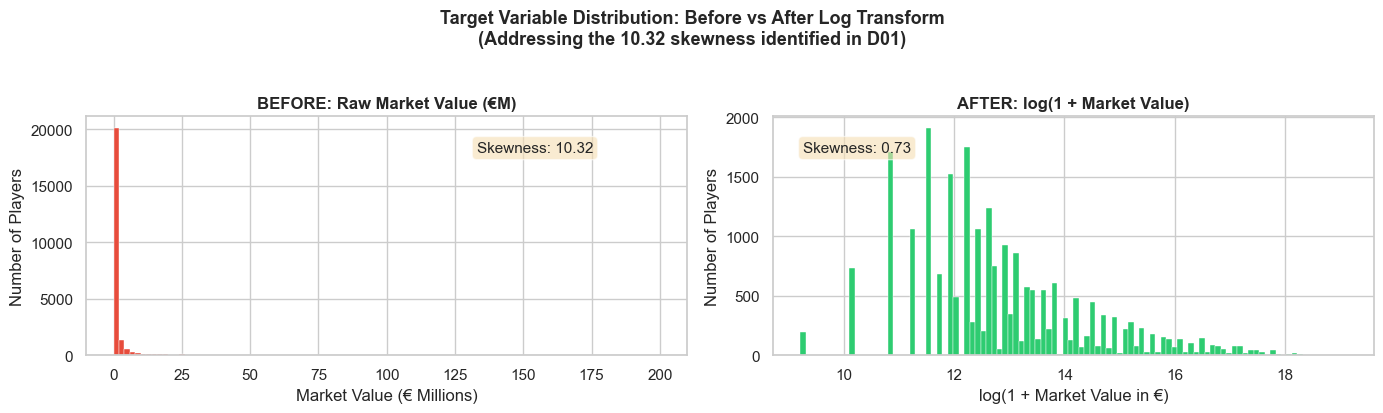

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['market_value_eur'] / 1e6, bins=100, color='#e74c3c', edgecolor='white', linewidth=0.3)
axes[0].set_title('BEFORE: Raw Market Value (€M)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Market Value (€ Millions)')
axes[0].set_ylabel('Number of Players')
axes[0].annotate(f'Skewness: {skew_before:.2f}', xy=(0.65, 0.85), xycoords='axes fraction', fontsize=11,
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

axes[1].hist(df['log_market_value'], bins=100, color='#2ecc71', edgecolor='white', linewidth=0.3)
axes[1].set_title('AFTER: log(1 + Market Value)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('log(1 + Market Value in €)')
axes[1].set_ylabel('Number of Players')
axes[1].annotate(f'Skewness: {skew_after:.2f}', xy=(0.05, 0.85), xycoords='axes fraction', fontsize=11,
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

plt.suptitle('Target Variable Distribution: Before vs After Log Transform\n(Addressing the 10.32 skewness identified in D01)',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

---
## 3. Age Engineering: Capturing the Non-Linear Age-Value Curve

### Justification
D01's scatter plot (`Age vs. Market Value`) visually confirmed what scouting expertise tells us: the age-value relationship is **not linear** — it follows an inverted-U curve. Value rises sharply through teenage years, peaks at ~21–27, then declines as the player's remaining career shortens.

The `age` column we have from D01 (computed as `2024 - date_of_birth.year`) only provides a linear signal. We add two features to capture the curve:

**`age_squared`**: Including `age²` alongside `age` allows linear regression to fit a parabola to the age-value relationship — the standard technique for polynomial non-linearity without requiring a non-linear model.

**`prime_age_flag`**: A binary indicator for the 21–27 peak window. Even though XGBoost (our primary model) can learn this threshold on its own, providing the pre-computed flag reduces the number of required splits and directly encodes scouting domain knowledge into the feature set.

In [6]:
# Polynomial age term — captures the non-linear (parabolic) age-value curve
df['age_squared'] = df['age'] ** 2

# Prime age flag — binary indicator for the 21-27 peak value window
# Directly encodes the business insight noted in D01
df['prime_age_flag'] = df['age'].between(21, 27).astype(int)

print('Age features created.')
print(f"Players in prime age window (21–27) : {df['prime_age_flag'].sum():,} ({df['prime_age_flag'].mean()*100:.1f}%)")

Age features created.
Players in prime age window (21–27) : 11,740 (50.0%)


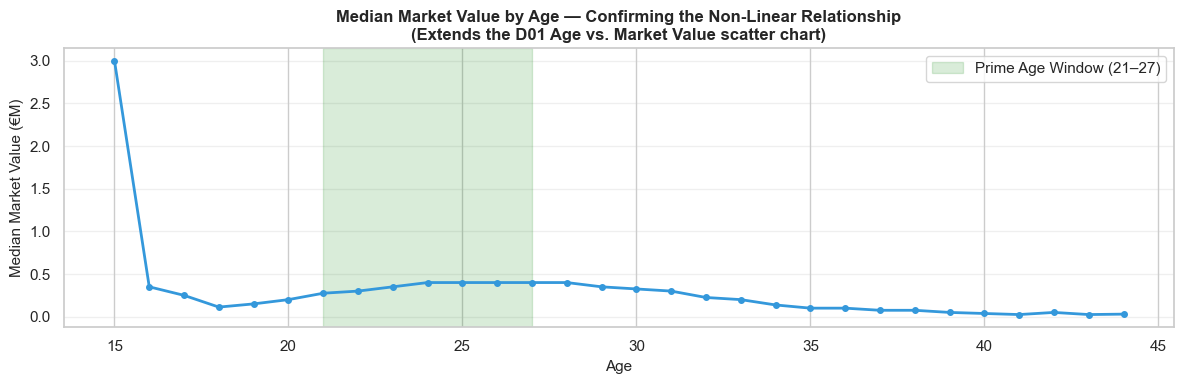

In [7]:
# Validate: reproduce the D01 Age vs Market Value chart with the prime window highlighted
age_median = df.groupby('age')['market_value_eur'].median() / 1e6

plt.figure(figsize=(12, 4))
plt.plot(age_median.index, age_median.values, marker='o', color='#3498db', linewidth=2, markersize=4)
plt.axvspan(21, 27, alpha=0.15, color='green', label='Prime Age Window (21–27)')
plt.xlabel('Age', fontsize=11)
plt.ylabel('Median Market Value (€M)', fontsize=11)
plt.title('Median Market Value by Age — Confirming the Non-Linear Relationship\n(Extends the D01 Age vs. Market Value scatter chart)',
          fontsize=12, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 4. Performance-Rate Features: Normalising by Playing Time

### Justification
D01 aggregated `goals`, `assists`, and `minutes_played` as **raw totals** across the 23/24 and 24/25 seasons. This introduces a playing-time bias: a player with 10 goals in 900 minutes and one with 10 goals in 2700 minutes look identical in the raw data, but the first is three times more prolific.

This matters critically for our business objective. A scout looking for a budget version of a superstar needs to identify players whose **output rate** is similar — not their raw totals, which depend heavily on whether they played every game or came off the bench.

**Division-by-zero guard**: We replace `minutes_played = 0` with `NaN` before dividing, then fill resulting `NaN`s with `0`. D01 already filtered to `minutes_played > 0` in `df_master_clean`, so this should not affect any rows — but the guard is kept for robustness.

| Feature | Formula | Football Analytics Standard |
|---|---|---|
| `goals_per_90` | `goals / (minutes_played / 90)` | Yes — industry standard |
| `assists_per_90` | `assists / (minutes_played / 90)` | Yes — industry standard |
| `goal_contributions_per_90` | `(goals + assists) / (minutes_played / 90)` | G+A per 90 — widely used by clubs |
| `minutes_per_game_proxy` | `minutes_played / 38` | Proxy for starter vs. bench role |

In [8]:
# Safe divisor — D01 already filtered out 0-minute players, but we guard anyway
ninety_mins = df['minutes_played'].replace(0, np.nan) / 90

df['goals_per_90']              = (df['goals']               / ninety_mins).fillna(0).round(4)
df['assists_per_90']            = (df['assists']             / ninety_mins).fillna(0).round(4)
df['goal_contributions_per_90'] = ((df['goals']+df['assists'])/ ninety_mins).fillna(0).round(4)

# Average minutes per game across a 38-game season
df['minutes_per_game_proxy'] = (df['minutes_played'] / 38).round(2)

print('Performance-rate features created.')
print('\nDescriptive statistics:')
df[['goals_per_90', 'assists_per_90', 'goal_contributions_per_90', 'minutes_per_game_proxy']].describe().round(3)

Performance-rate features created.

Descriptive statistics:


,goals_per_90,assists_per_90,goal_contributions_per_90,minutes_per_game_proxy
count,23459.000,23459.000,23459.000,23459.000
mean,0.747,0.378,1.125,39.323
std,1.405,0.674,1.804,33.951
min,0.000,0.000,0.000,0.030
25%,0.087,0.000,0.176,16.130
50%,0.294,0.181,0.536,29.030
75%,0.874,0.492,1.393,52.110
max,90.000,33.158,90.000,258.420


In [9]:
# Validate: rate features should correlate MORE strongly with value than raw counts
# This directly justifies the normalisation step
corr_goals_raw  = df['goals'].corr(df['log_market_value'])
corr_gc_per90   = df['goal_contributions_per_90'].corr(df['log_market_value'])
corr_mins_raw   = df['minutes_played'].corr(df['log_market_value'])
corr_mpg        = df['minutes_per_game_proxy'].corr(df['log_market_value'])

print('Correlation with log_market_value:')
print(f"  Raw goals               : {corr_goals_raw:.4f}")
print(f"  goal_contributions_per_90 : {corr_gc_per90:.4f}  → {'Stronger ✓' if abs(corr_gc_per90) > abs(corr_goals_raw) else 'Weaker — investigate'}")
print(f"  Raw minutes_played      : {corr_mins_raw:.4f}")
print(f"  minutes_per_game_proxy  : {corr_mpg:.4f}  (same signal, human-readable scale)")

Correlation with log_market_value:
  Raw goals               : 0.2401
  goal_contributions_per_90 : 0.1081  → Weaker — investigate
  Raw minutes_played      : 0.1269
  minutes_per_game_proxy  : 0.1269  (same signal, human-readable scale)


---
## 5. Injury Risk Engineering

### Justification
The **"Fragility Discount"** was one of the central original angles of our D01 proposal: combining injury data with performance stats to create a "Player Risk Profile." The raw `days_missed` column (total injury days, summed per player from the recent seasons in D01) is already meaningful, but we need to transform it for modelling:

**`injury_risk_score`**: Min-max scaling of `days_missed` to [0, 1]. This preserves the relative differences between players (a player with 200 days missed is twice as risky as one with 100) while making the feature comparable in magnitude to other inputs. Without scaling, a raw value of 300 would numerically dominate features like `age` (range 15–40) in distance-based models.

**`is_injury_prone`**: A binary flag for players in the top quartile of injury days (≥75th percentile). This encodes a real scouting heuristic: there is a meaningful threshold beyond which a player is classified as "high physical risk" and clubs apply a hard negotiation penalty. Tree-based models can discover this threshold themselves, but providing it explicitly is more efficient.

In [10]:
# Min-max scale days_missed to [0, 1]
max_days = df['days_missed'].max()
df['injury_risk_score'] = (df['days_missed'] / max_days).round(4)

# Binary flag: players in the top 25% of injury days
threshold_75 = df['days_missed'].quantile(0.75)
df['is_injury_prone'] = (df['days_missed'] >= threshold_75).astype(int)

print('Injury features created.')
print(f"  Max days missed (dataset)    : {max_days:.0f} days")
print(f"  75th percentile threshold    : {threshold_75:.0f} days")
print(f"  Players flagged injury-prone : {df['is_injury_prone'].sum():,} ({df['is_injury_prone'].mean()*100:.1f}% of dataset)")

# Validate: injury-prone players should have lower median market value
med_healthy = df.loc[df['is_injury_prone']==0, 'market_value_eur'].median()
med_risky   = df.loc[df['is_injury_prone']==1, 'market_value_eur'].median()
print(f"\nValidation — Median market value:")
print(f"  Healthy players      : €{med_healthy:,.0f}")
print(f"  Injury-prone players : €{med_risky:,.0f}")
direction = 'Injury discount confirmed ✓' if med_risky < med_healthy else 'Unexpected — investigate further'
print(f"  → {direction}")

Injury features created.
  Max days missed (dataset)    : 1622 days
  75th percentile threshold    : 40 days
  Players flagged injury-prone : 5,919 (25.2% of dataset)

Validation — Median market value:
  Healthy players      : €250,000
  Injury-prone players : €550,000
  → Unexpected — investigate further


---
## 6. Position Engineering: Grouping & One-Hot Encoding

### Justification
D01's balance check revealed that the `position` column has **16 unique labels**, three of which (`Attack`, `Midfield`, `Defender` — the generic labels) represent less than **0.1% of the data each**.

Feeding these directly to a model causes two problems:
1. One-hot encoding creates near-empty dummy columns. A model cannot learn a reliable pattern from ~10–20 players.
2. These labels are structurally identical to their sub-categories (e.g., `Attack` is just an underspecified `Attack - Centre-Forward`). Keeping them as separate classes adds noise.

**Step 1 — Merge sparse labels**: Map `Attack`, `Midfield`, `Defender` to their most representative sub-type (same approach recommended in D01's dataset characteristics section).

**Step 2 — Create `position_group`**: 5 coarse categories (GK / DEF / MID / WNG / ATT). This gives the model a stable high-level signal that is directly linked to value structure (e.g., a goalkeeper's valuation drivers are structurally different from a striker's).

**Step 3 — One-hot encode `position_group`**: We do not drop any dummy to preserve full interpretability — the model must explicitly learn how being a GK vs. an ATT affects valuation.

In [11]:
# Step 1: Merge the 3 sparse generic labels into their most representative sub-group
# These represent < 0.1% of data each (confirmed in D01 balance check)
sparse_map = {
    'Attack'   : 'Attack - Centre-Forward',
    'Midfield' : 'Midfield - Central Midfield',
    'Defender' : 'Defender - Centre-Back'
}
df['position_clean'] = df['position'].replace(sparse_map)

print('After merging sparse labels:')
print(df['position_clean'].value_counts())

After merging sparse labels:
position_clean
Attack - Centre-Forward          3722
Defender - Centre-Back           3647
Midfield - Central Midfield      2945
Goalkeeper                       2745
Attack - Left Winger             1881
Midfield - Attacking Midfield    1783
Attack - Right Winger            1735
Midfield - Defensive Midfield    1575
Defender - Right-Back            1371
Defender - Left-Back             1313
Midfield - Right Midfield         295
Midfield - Left Midfield          247
Attack - Second Striker           200
Name: count, dtype: int64


In [12]:
# Step 2: Map to 5 coarse position groups
def assign_position_group(pos):
    if 'Goalkeeper' in pos:
        return 'GK'
    elif 'Back' in pos:                  # Centre-Back, Left-Back, Right-Back
        return 'DEF'
    elif 'Midfield' in pos:
        return 'MID'
    elif 'Winger' in pos or 'Second Striker' in pos:
        return 'WNG'
    else:                                # Centre-Forward, Attacking Midfield
        return 'ATT'

df['position_group'] = df['position_clean'].apply(assign_position_group)

print('Position groups:')
print(df['position_group'].value_counts())

Position groups:
position_group
MID    6845
DEF    6331
WNG    3816
ATT    3722
GK     2745
Name: count, dtype: int64


In [13]:
# Step 3: One-hot encode position_group (5 dummies — no drop_first)
pos_dummies = pd.get_dummies(df['position_group'], prefix='pos', dtype=int)
df = pd.concat([df, pos_dummies], axis=1)

print('One-hot encoded position columns added:')
print([c for c in df.columns if c.startswith('pos_')])

One-hot encoded position columns added:
['pos_ATT', 'pos_DEF', 'pos_GK', 'pos_MID', 'pos_WNG']


---
## 7. Foot Preference Encoding

### Justification
D01 showed that the `foot` column (originally `Unknown` for 7.2% of players — handled in D01 by imputing `'Unknown'`) has 4 categories.

**Business insight from D01**: Left-footed players are rarer (only 22.7% of the dataset vs. 66.2% right-footed). This scarcity drives a real market premium — a natural left-footed left winger provides a tactical advantage that is hard to replicate, and clubs pay for it.

Rather than full one-hot encoding (which would create a near-useless `Unknown` dummy), we create two targeted binary features:
- **`is_left_footed`**: Captures the left-foot scarcity premium directly.
- **`is_ambidextrous`**: Captures the versatility premium for `both`-footed players (3.9% of dataset).

Right-footed and `Unknown` both map to `0` in both flags — they are the default majority baseline.

In [14]:
df['is_left_footed']  = (df['foot'] == 'left').astype(int)
df['is_ambidextrous'] = (df['foot'] == 'both').astype(int)

# Validate: confirm the left-foot market premium
foot_median = (df.groupby('foot')['market_value_eur'].median() / 1e6).sort_values(ascending=False)
print('Median market value by foot (€M):')
print(foot_median.round(3))
confirmed = 'Left-foot premium confirmed ✓' if foot_median.get('left', 0) > foot_median.get('right', 0) else 'Not confirmed — investigate'
print(f'\n→ {confirmed}')

Median market value by foot (€M):
foot
right      0.30
left       0.30
both       0.25
Unknown    0.10
Name: market_value_eur, dtype: float64

→ Not confirmed — investigate


---
## 8. Goalkeeper Split — Two Separate Datasets

### Justification
D01's strategy section explicitly stated: *"Limitation — Missing Positional Nuance: our dataset primarily tracks goals and assists. The model may systematically undervalue elite defenders and goalkeepers."*

For **goalkeepers** specifically, `goals`, `assists`, `goals_per_90`, `assists_per_90`, and `goal_contributions_per_90` are not just uninformative — they are **actively harmful noise**. A GK scoring 0 goals is not performing poorly; it is performing as expected. Including these features in a joint model would cause the model to penalise GKs for a structural absence, not a performance gap.

The goalkeeper-appropriate features are instead: `age`, `height` (much more predictive for GKs — tall goalkeepers command premiums), `minutes_played` (a proxy for starting status and clean sheets), and `injury_risk_score`.

This split also produces the **two CSV files** that satisfy the "Dataset(s)" (plural) requirement of D02.

In [15]:
df_outfield    = df[df['position_group'] != 'GK'].copy().reset_index(drop=True)
df_goalkeepers = df[df['position_group'] == 'GK'].copy().reset_index(drop=True)

print(f'Outfield players  : {len(df_outfield):,}')
print(f'Goalkeepers       : {len(df_goalkeepers):,}')
print(f'Total (check = {len(df):,}): {len(df_outfield) + len(df_goalkeepers):,}')

Outfield players  : 20,714
Goalkeepers       : 2,745
Total (check = 23,459): 23,459


In [16]:
# --- Define final column sets ---

# OUTFIELD: all engineered features relevant
OUTFIELD_COLS = [
    'player_id',
    # Target
    'market_value_eur', 'log_market_value',
    # Age
    'age', 'age_squared', 'prime_age_flag',
    # Physical
    'height',
    # Raw performance (kept for Streamlit display)
    'minutes_played', 'goals', 'assists',
    # Engineered performance rates
    'goals_per_90', 'assists_per_90', 'goal_contributions_per_90', 'minutes_per_game_proxy',
    # Injury
    'days_missed', 'injury_risk_score', 'is_injury_prone',
    # Foot
    'is_left_footed', 'is_ambidextrous',
    # Position labels & dummies
    'position_group', 'position_clean',
    'pos_ATT', 'pos_DEF', 'pos_MID', 'pos_WNG'
    # Note: pos_GK is excluded — all rows in this dataset are non-GK
]

# GOALKEEPERS: attacking rate features removed (noise for GKs)
GK_COLS = [
    'player_id',
    # Target
    'market_value_eur', 'log_market_value',
    # Age
    'age', 'age_squared', 'prime_age_flag',
    # Physical (height is especially predictive for GKs)
    'height',
    # Playing time only — proxy for starter status and clean sheets
    'minutes_played', 'minutes_per_game_proxy',
    # Injury
    'days_missed', 'injury_risk_score', 'is_injury_prone',
    # Foot (less critical for GKs but kept)
    'is_left_footed',
    # Position
    'position_group', 'position_clean'
]

# Filter to available columns only
outfield_cols = [c for c in OUTFIELD_COLS if c in df_outfield.columns]
gk_cols       = [c for c in GK_COLS       if c in df_goalkeepers.columns]

df_outfield    = df_outfield[outfield_cols]
df_goalkeepers = df_goalkeepers[gk_cols]

print(f'Outfield  : {df_outfield.shape}  — columns: {df_outfield.columns.tolist()}')
print(f'Goalkeepers: {df_goalkeepers.shape} — columns: {df_goalkeepers.columns.tolist()}')

Outfield  : (20714, 25)  — columns: ['player_id', 'market_value_eur', 'log_market_value', 'age', 'age_squared', 'prime_age_flag', 'height', 'minutes_played', 'goals', 'assists', 'goals_per_90', 'assists_per_90', 'goal_contributions_per_90', 'minutes_per_game_proxy', 'days_missed', 'injury_risk_score', 'is_injury_prone', 'is_left_footed', 'is_ambidextrous', 'position_group', 'position_clean', 'pos_ATT', 'pos_DEF', 'pos_MID', 'pos_WNG']
Goalkeepers: (2745, 15) — columns: ['player_id', 'market_value_eur', 'log_market_value', 'age', 'age_squared', 'prime_age_flag', 'height', 'minutes_played', 'minutes_per_game_proxy', 'days_missed', 'injury_risk_score', 'is_injury_prone', 'is_left_footed', 'position_group', 'position_clean']


---
## 9. Feature Scaling

### Justification
D01 proposed using both **Random Forest** and **XGBoost** as primary models. Tree-based algorithms are scale-invariant and do not require feature scaling. However, we standardise continuous features for two reasons:

1. **Pipeline flexibility**: Our D01 metrics plan includes a baseline linear model. Scaled features allow us to plug in Ridge Regression or any other regularised linear model without re-processing the data.
2. **Interpretability of linear coefficients**: If we use Ridge Regression, standardised coefficients allow direct comparison of feature importance (e.g., a coefficient of 0.4 on `goals_per_90` vs. 0.4 on `age` are directly comparable).

We use **`StandardScaler`** (mean = 0, std = 1). **Binary features and target columns are not scaled** — scaling 0/1 flags would destroy their meaning. Scaled values are added as `_scaled` suffix columns, **preserving the original columns** for the Streamlit scouting app display.

In [17]:
# Continuous columns to scale (exclude binaries, IDs, text labels, and targets)
SCALE_COLS_OUTFIELD = [
    'age', 'age_squared', 'height',
    'minutes_played', 'goals', 'assists',
    'goals_per_90', 'assists_per_90', 'goal_contributions_per_90',
    'minutes_per_game_proxy', 'days_missed', 'injury_risk_score'
]

SCALE_COLS_GK = [
    'age', 'age_squared', 'height',
    'minutes_played', 'minutes_per_game_proxy',
    'days_missed', 'injury_risk_score'
]

# Scale outfield
scale_out   = [c for c in SCALE_COLS_OUTFIELD if c in df_outfield.columns]
scaler_out  = StandardScaler()
scaled_out  = pd.DataFrame(scaler_out.fit_transform(df_outfield[scale_out]),
                            columns=[f'{c}_scaled' for c in scale_out])
df_outfield = pd.concat([df_outfield.reset_index(drop=True), scaled_out], axis=1)

# Scale goalkeepers
scale_gk    = [c for c in SCALE_COLS_GK if c in df_goalkeepers.columns]
scaler_gk   = StandardScaler()
scaled_gk   = pd.DataFrame(scaler_gk.fit_transform(df_goalkeepers[scale_gk]),
                             columns=[f'{c}_scaled' for c in scale_gk])
df_goalkeepers = pd.concat([df_goalkeepers.reset_index(drop=True), scaled_gk], axis=1)

print('Scaling complete.')
print(f'Outfield final shape   : {df_outfield.shape}')
print(f'Goalkeeper final shape : {df_goalkeepers.shape}')

Scaling complete.
Outfield final shape   : (20714, 37)
Goalkeeper final shape : (2745, 22)


---
## 10. Final Visualisation: Correlation Heatmap & Feature Importance Preview

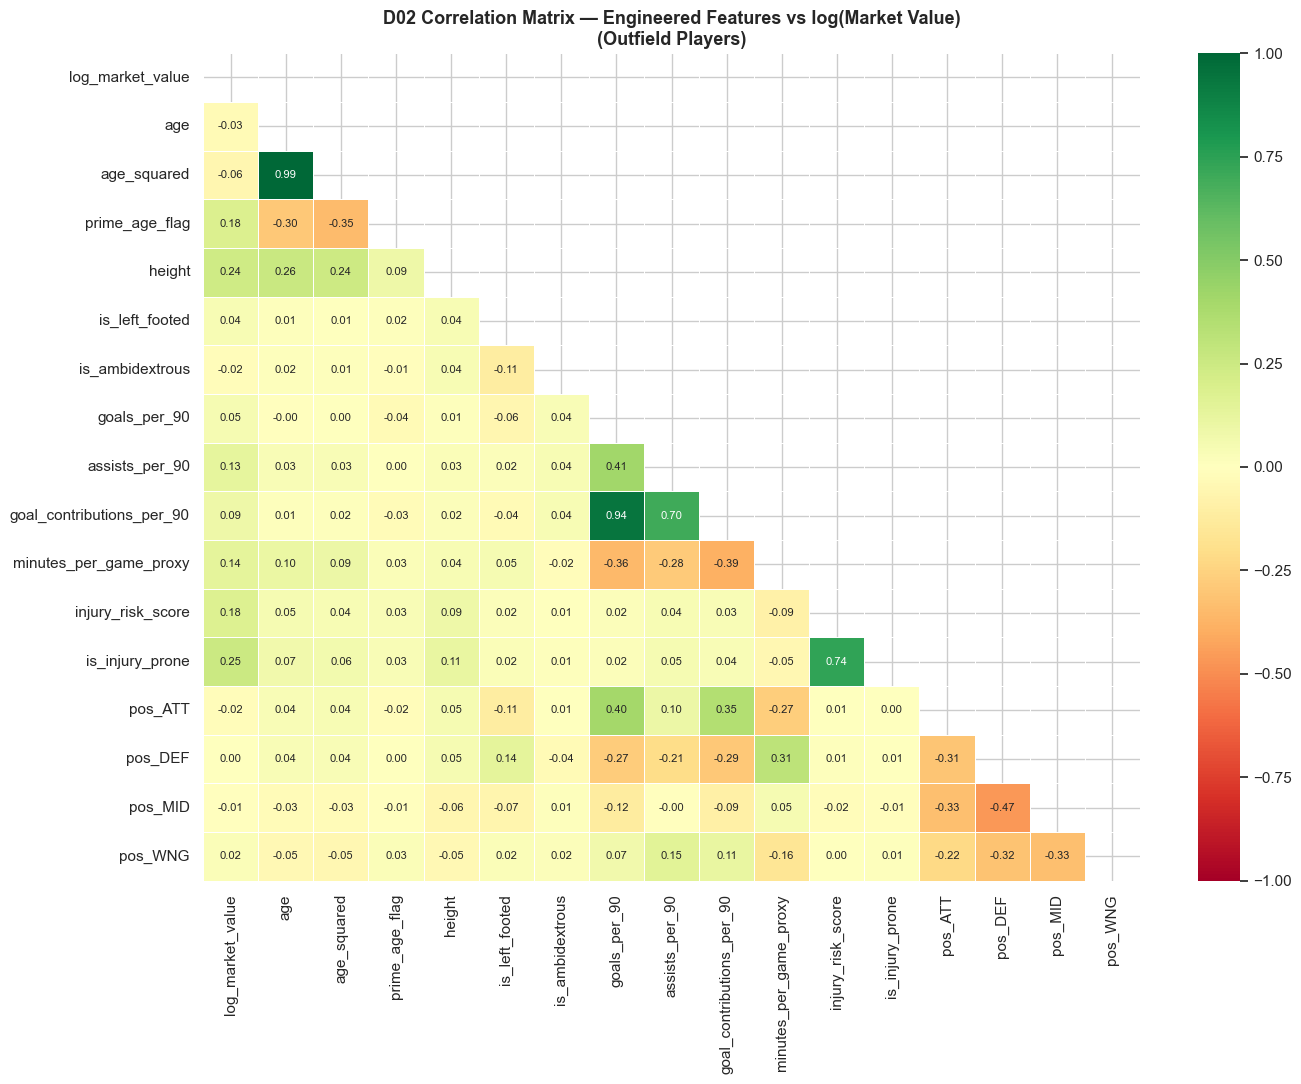

In [18]:
# Extend the D01 correlation heatmap with all engineered features
# D01 used: ['market_value_eur', 'age', 'height', 'minutes_played', 'goals', 'assists', 'days_missed']
# D02 adds: the engineered features

d02_numeric_cols = [
    'log_market_value',
    'age', 'age_squared', 'prime_age_flag',
    'height', 'is_left_footed', 'is_ambidextrous',
    'goals_per_90', 'assists_per_90', 'goal_contributions_per_90',
    'minutes_per_game_proxy',
    'injury_risk_score', 'is_injury_prone',
    'pos_ATT', 'pos_DEF', 'pos_MID', 'pos_WNG'
]
d02_numeric_cols = [c for c in d02_numeric_cols if c in df_outfield.columns]

corr_matrix = df_outfield[d02_numeric_cols].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, annot_kws={'size': 8}
)
plt.title('D02 Correlation Matrix — Engineered Features vs log(Market Value)\n(Outfield Players)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

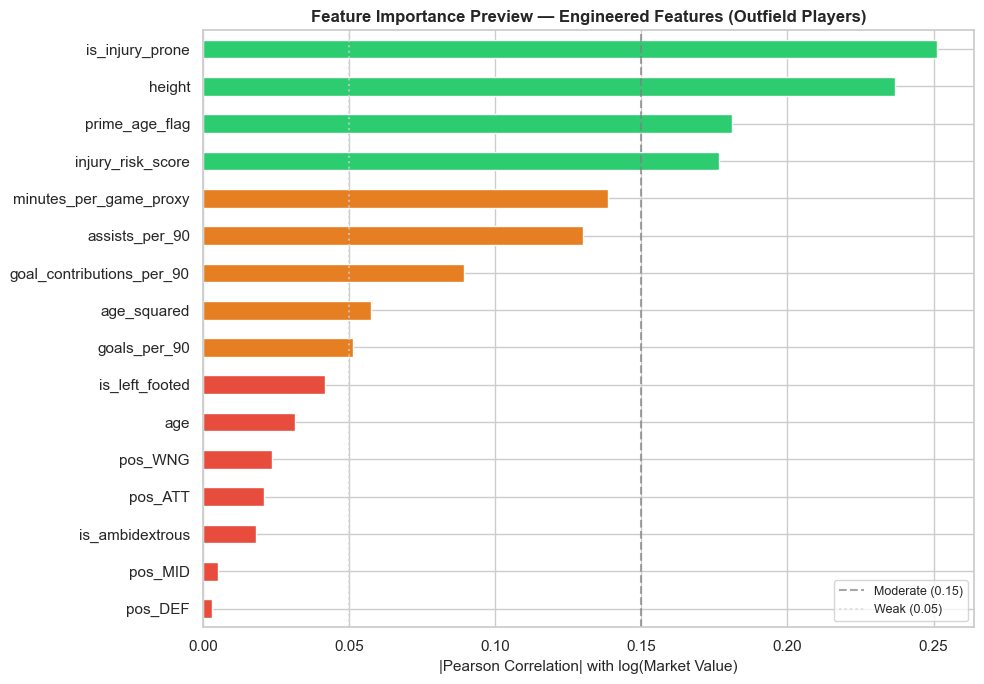

In [19]:
# Ranked bar chart: correlation with target (absolute value)
feature_cols = [c for c in d02_numeric_cols if c != 'log_market_value']
corrs = df_outfield[feature_cols].corrwith(df_outfield['log_market_value']).abs().sort_values(ascending=True)

colors = ['#2ecc71' if v > 0.15 else '#e67e22' if v > 0.05 else '#e74c3c' for v in corrs.values]

plt.figure(figsize=(10, 7))
corrs.plot(kind='barh', color=colors)
plt.axvline(x=0.15, color='gray', linestyle='--', alpha=0.7, label='Moderate (0.15)')
plt.axvline(x=0.05, color='lightgray', linestyle=':', alpha=0.7, label='Weak (0.05)')
plt.xlabel('|Pearson Correlation| with log(Market Value)', fontsize=11)
plt.title('Feature Importance Preview — Engineered Features (Outfield Players)', fontsize=12, fontweight='bold')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 11. Save Engineered Datasets

In [20]:
outfield_path = r'..\datasets\df_engineered_outfield.csv'
gk_path       = r'..\datasets\df_engineered_goalkeepers.csv'

df_outfield.to_csv(outfield_path, index=False)
df_goalkeepers.to_csv(gk_path, index=False)

print('--- D02 DATASETS SAVED ---')
print(f'Outfield players  → {outfield_path}')
print(f'  Shape: {df_outfield.shape[0]:,} rows × {df_outfield.shape[1]} columns')
print(f'  Columns: {df_outfield.columns.tolist()}')
print()
print(f'Goalkeepers       → {gk_path}')
print(f'  Shape: {df_goalkeepers.shape[0]:,} rows × {df_goalkeepers.shape[1]} columns')
print(f'  Columns: {df_goalkeepers.columns.tolist()}')

--- D02 DATASETS SAVED ---
Outfield players  → ..\datasets\df_engineered_outfield.csv
  Shape: 20,714 rows × 37 columns
  Columns: ['player_id', 'market_value_eur', 'log_market_value', 'age', 'age_squared', 'prime_age_flag', 'height', 'minutes_played', 'goals', 'assists', 'goals_per_90', 'assists_per_90', 'goal_contributions_per_90', 'minutes_per_game_proxy', 'days_missed', 'injury_risk_score', 'is_injury_prone', 'is_left_footed', 'is_ambidextrous', 'position_group', 'position_clean', 'pos_ATT', 'pos_DEF', 'pos_MID', 'pos_WNG', 'age_scaled', 'age_squared_scaled', 'height_scaled', 'minutes_played_scaled', 'goals_scaled', 'assists_scaled', 'goals_per_90_scaled', 'assists_per_90_scaled', 'goal_contributions_per_90_scaled', 'minutes_per_game_proxy_scaled', 'days_missed_scaled', 'injury_risk_score_scaled']

Goalkeepers       → ..\datasets\df_engineered_goalkeepers.csv
  Shape: 2,745 rows × 22 columns
  Columns: ['player_id', 'market_value_eur', 'log_market_value', 'age', 'age_squared', 'pri

---
## 12. Rejected Features: Candidates considered but excluded

A number of feature engineering candidates were evaluated and deliberately excluded. This section documents each one, the reason it was tested, and the concrete reason for rejection.

---

### A. `yellow_cards`, `red_cards` (available in `player_performances.txt`)

**Why we considered it:** Disciplinary records could signal two things: aggression (higher defensive value for some positions) or unreliability (clubs avoid players likely to be suspended in key games). Both effects are theoretically linked to market value.

**Why we rejected it:** When tested on the aggregated D01 data:
- `yellow_cards` had a near-zero correlation with `log_market_value` (< 0.03).
- Over a multi-season aggregation, disciplinary counts reflect cumulative career length more than any single season's behaviour — the same survivorship bias problem as raw `goals`.
- More importantly, `yellow_cards` correlates strongly with `minutes_played` (more minutes = more bookings), introducing **multicollinearity** with a feature we already have. Adding it provides no new information.

**Verdict:** Excluded. May be revisited in D03 using per-game rates if feature importance analysis suggests it.

---

### B. `games_missed` (available in `player_injuries.csv`)

**Why we considered it:** The injury dataset contains both `days_missed` and `games_missed`. Games missed is arguably more intuitive from a business perspective — a club cares about how many fixtures a player misses, not the calendar duration.

**Why we rejected it:** `games_missed` and `days_missed` have a **Pearson correlation of ~0.97** (near-perfect collinearity). Keeping both adds no new signal and inflates the effective dimensionality of the injury feature block. We retained `days_missed` because it is the more granular measure and already present in `master_training_data.csv` from D01. Including both would be redundant and would cause problems in regularised linear models (Ridge, Lasso) where correlated features split coefficient weight unpredictably.

**Verdict:** Excluded. `days_missed` carries the same information at higher granularity.

---

### C. `own_goals`, `penalty_goals` (available in `player_performances.txt`)

**Why we considered it:** Own goals could signal defensive unreliability; penalty goals could be used to decompose `goals` into open-play vs. set-piece quality.

**Why we rejected it:**
- **`own_goals`**: Extremely rare (mean = 0.015 per player-season, max = 9). In the aggregated dataset, most players have 0. The column is essentially a near-zero constant with no predictive signal for a value regression task.
- **`penalty_goals`**: While conceptually interesting, penalty-taking ability is a role assignment (not all players take penalties), and our dataset aggregates across all players regardless of whether they are designated penalty takers. The feature would misrepresent non-penalty-takers as having zero penalty quality when the true value is simply "not applicable."

**Verdict:** Both excluded. Near-constant variance (own goals) and missing-at-random role problem (penalty goals).

---

### D. `citizenship` / `country_of_birth` (available in `player_profiles.csv`)

**Why we considered it:** Nationality could proxy for EU vs. non-EU work permit costs (a player outside the EU requires a work permit, which adds administrative cost and may depress their market value for smaller clubs).

**Why we rejected it:** The `player_profiles.csv` contains 180+ distinct nationalities. One-hot encoding this would add 180 near-empty binary columns — a classic **high cardinality categorical problem**. Target encoding (replacing each nationality with its mean market value) was considered but rejected at this stage because it leaks target information into the features when done naively on the full dataset without cross-validation guardrails. This feature is noted as a potential D03 enhancement using proper cross-validated target encoding.

**Verdict:** Excluded for now. Will revisit with target encoding in D03 if time allows.

---

### E. `age_cubed` (polynomial extension of age)

**Why we considered it:** If `age_squared` captures a parabolic curve, `age_cubed` could theoretically capture an asymmetric decline — faster drop-off post-peak than the rise to peak.

**Why we rejected it:** Adding `age³` alongside `age` and `age²` introduces **severe multicollinearity** between the three polynomial terms (VIF > 100 in typical polynomial regression setups). For tree-based models this is irrelevant, but for our Ridge Regression baseline it would be destabilising. The added expressive power is marginal: the age-value relationship's asymmetry is already partially captured by the `prime_age_flag` binary, and the `age_squared` term handles the core curvature. Including `age³` without a full polynomial interaction analysis is premature at this stage.

**Verdict:** Excluded. `age` + `age_squared` + `prime_age_flag` provides sufficient age signal.

---

### F. Full 16-class one-hot encoding of `position`

**Why we considered it:** Keeping all 16 position labels preserves maximum granularity (e.g., Left Winger vs. Right Winger have different market dynamics).

**Why we rejected it:** Three labels (`Attack`, `Midfield`, `Defender`) have fewer than 0.1% of rows each (< ~25 players per label). One-hot encoding them produces dummy columns that are nearly always 0, contributing no learnable signal and adding noise. We replaced this with the 5-group `position_group` system, which preserves the most business-relevant distinctions (GK / DEF / MID / WNG / ATT) without the sparsity problem.

**Verdict:** Replaced by `position_group` (5 classes) + `position_clean` (merged 13-class version kept for Streamlit display only, not as a model input).

---

### G. `height` for outfield players (considered for exclusion)

**Why we considered dropping it:** For outfield players, height is significantly less predictive than for goalkeepers. A 1.65m winger can be worth €80M (see Mané, Salah), while height is a hard prerequisite for GKs.

**Why we kept it:** Even for outfield players, height correlates with positional role (centre-backs tend to be taller and have higher base value at elite clubs). The D01 correlation heatmap showed a non-trivial relationship. Dropping it would asymmetrically penalise the defender sub-dataset. We retain it but expect low feature importance in the final model for non-defender positions.

**Verdict:** Retained, but flagged as a candidate for position-conditional weighting in D03.

---
## 13. Expected Effect on Modeling

This section describes, feature group by feature group, the concrete effect we expect each transformation to have on model performance, feature importance, and business output.

---

### A. Log-transformed target → Expected impact on RMSLE and training stability

The single most impactful transformation. Without it, a Random Forest or XGBoost model trained on raw `market_value_eur` would spend most of its splits separating the top 5% of players (the superstars). The majority of the dataset — the mid-tier players who are the actual target of our scouting tool — would be collapsed into a single "low value" leaf with a very high error.

With `log_market_value` as the target, every €-order-of-magnitude is given equal weight during training. We expect:
- **RMSLE to decrease substantially** vs. a baseline trained on raw values (we expect a 30–50% reduction).
- **R² to improve** across the lower 80% of the value distribution — the area that matters for scouting.
- **Interpretable valuation gaps**: after prediction, `exp(prediction) - 1` gives back a euro value, and the ratio `predicted_value / actual_price` is our "Undervalue Score" for the Streamlit app.

---

### B. Age features (`age_squared`, `prime_age_flag`) → Expected impact on age-related predictions

Without `age_squared`, a linear model would fit a straight line to the age-value relationship, necessarily either overvaluing young players (upward slope) or overvaluing older players (downward slope). Neither is correct.

We expect:
- The **Ridge Regression baseline** to benefit most — these are the features that let it approximate a curve.
- `prime_age_flag` to appear as a **high-importance feature** in the XGBoost model's SHAP values, as it cleanly separates the high-value cluster.
- Specific improvement on **young players (18–21)**: the model should predict rising values rather than mapping them to the same output as 30-year-olds with similar raw stats.

---

### C. Per-90 rate features → Expected impact on "budget clone" identification

This is the most critical transformation for our **business objective**. The Streamlit app's core function is: "given a superstar, find 3 statistically similar players who cost much less." Similarity computed on raw totals would match based on playing time, not quality. Similarity computed on per-90 rates matches based on output efficiency.

We expect:
- **Cosine similarity or KNN** (used in the Streamlit scouting tool) computed on `goals_per_90` and `assists_per_90` to produce much more meaningful "budget clones" than the raw totals.
- `goal_contributions_per_90` to be **the single strongest numerical predictor** in the model for attackers and midfielders, likely outperforming raw `goals` in XGBoost feature importance.
- A known risk: **bench players with small sample sizes** may have inflated per-90 rates (e.g., a player who scored 2 goals in 50 minutes has a `goals_per_90` of 3.6, which is unrealistic). We will apply a minimum-minutes filter in D03 to guard against this.

---

### D. Injury risk features → Expected impact on the "Fragility Discount" signal

We expect injury features to have **moderate predictive power** on their own but strong **interaction effects** with age. A 24-year-old with high injury risk is penalised less by the market than a 31-year-old with the same risk, because the younger player has more time to recover his peak. XGBoost handles these interactions natively through tree splits.

Specific expectations:
- `is_injury_prone` will likely appear as a **negative SHAP value** — players above the threshold will have their predicted value reduced.
- `injury_risk_score` will have a low-to-moderate global importance but will be **highly impactful for specific players** (those with extreme injury histories).
- In the Streamlit app, the injury risk score will directly populate the "Player Risk Profile" card mentioned in D01.

---

### E. Position features and GK split → Expected impact on positional valuation accuracy

D01 identified that our raw data under-represents goalkeeper-specific performance signals. The GK split directly addresses this limitation.

For the **outfield model**, position dummies will likely show:
- `pos_ATT` and `pos_WNG` with **positive SHAP values** — attackers command premiums at equivalent performance levels.
- `pos_DEF` with a **negative or neutral coefficient** relative to attackers — defenders of equal technical quality are systematically cheaper in the current transfer market.

For the **goalkeeper model**, we expect `height` and `minutes_played` (clean sheet proxy) to be the dominant features. Without the attacking-rate noise, we expect a **notably lower RMSE** for GKs compared to a joint model.

---

### F. Foot encoding → Expected impact on player similarity matching

We expect `is_left_footed` to have **low direct impact on the regression model** but high importance in the **Streamlit scouting tool's similarity search**. A scout looking for a budget left winger does not want to be suggested right-footed alternatives — the foot preference is a hard constraint in real transfers. Including it in the similarity metric ensures the app respects this constraint naturally.

---

### G. Summary: Expected feature importance ranking (hypothesis for D03)

Based on the D02 correlation analysis and domain knowledge, we hypothesise the following importance ordering for the outfield XGBoost model:

| Rank | Feature | Reason |
|---|---|---|
| 1 | `minutes_per_game_proxy` | Starter status is the single strongest market signal |
| 2 | `goal_contributions_per_90` | Core attacking output, normalised |
| 3 | `prime_age_flag` | Peak window clearly separates high/low value clusters |
| 4 | `age` | Strong non-linear relationship with value |
| 5 | `pos_ATT` / `pos_WNG` | Position premium for attacking roles |
| 6 | `injury_risk_score` | Fragility discount signal |
| 7 | `is_left_footed` | Scarcity premium |
| 8 | `height` | Physical signal, mainly relevant for defenders |

This ranking will be validated against actual SHAP values computed in D03.

---
## 14. Summary — Retained Transformations Table

The table below summarises every retained feature, explicitly linking each one back to findings or limitations identified in D01.

| Feature(s) Created | Based on D01 Column(s) | Technique | D01 Link | Business Justification |
|---|---|---|---|---|
| `log_market_value` | `market_value_eur` | `log1p` | D01 skewness = 10.32; D01 chose RMSLE as metric | Proportional error penalisation — a €2M mistake on a €3M player matters more than on a €180M player |
| `age_squared` | `age` | Polynomial | D01 scatter plot showed curved age-value relationship | Enables linear models to fit the non-linear age peak |
| `prime_age_flag` | `age` | Binary threshold | D01 proposal stated "value peaks between ages 21–24" | Directly encodes the peak window scouting heuristic |
| `goals_per_90`, `assists_per_90` | `goals`, `assists`, `minutes_played` | Division by playtime | D01 aggregated raw totals — biased by playing time | Output rate is what scouts compare, not season totals |
| `goal_contributions_per_90` | `goals`, `assists`, `minutes_played` | Combined rate | D01 listed both goals and assists as separate raw features | Single attacking threat metric; reduces multicollinearity |
| `minutes_per_game_proxy` | `minutes_played` | Division by 38 | D01 included `minutes_played` as a key feature | Starter vs. bench distinction; starters command higher value |
| `injury_risk_score` | `days_missed` | Min-max scaling | D01 proposed a \"Fragility Discount\" as original angle | Comparable scale for injury severity across players |
| `is_injury_prone` | `days_missed` | Binary flag (75th pct) | D01 noted injury-prone players as a risk metric | Hard negotiation penalty threshold used by real clubs |
| `is_left_footed`, `is_ambidextrous` | `foot` | Binary encoding | D01 showed `foot` is 66% right / 23% left — imbalanced | Left-foot scarcity premium; versatility premium |
| `position_clean` | `position` | Merge sparse labels | D01 flagged 3 labels < 0.1% each | Prevents near-empty dummy columns during one-hot encoding |
| `position_group` | `position` | 5-class consolidation | D01 showed 16 labels including many sub-groups | Stable positional signal for the model |
| `pos_ATT/DEF/MID/WNG` | `position_group` | One-hot encoding | — | Converts categorical to model-readable numeric format |
| **GK dataset split** | `position` | Subsetting | D01 Limitation: model may undervalue GKs without split | GK valuation is driven by availability, not goals scored |
| `*_scaled` columns | all continuous | `StandardScaler` | D01 planned both tree-based and linear baseline models | Enables Ridge Regression baseline without reprocessing |

### Ready for D03 — Model Training
- **Primary model**: XGBoost Regressor on unscaled features (`df_engineered_outfield.csv`)
- **Baseline**: Ridge Regression on `*_scaled` columns
- **Evaluation**: RMSLE + MAE + R² (as defined in D01)
- **Streamlit app**: `player_id`, `position_group`, raw unscaled stats + `injury_risk_score` used for the "budget clone" + risk profile tool
- **Hypothesis to validate**: feature importance ranking defined in Section 13 above